# Data 304 — NLP Wrangling Demo

## Environment setup
Run this once if needed:
```bash
pip install spacy pandas matplotlib
python -m spacy download en_core_web_sm
```


In [13]:
# Imports and model load
import spacy
from spacy import displacy
from spacy.matcher import Matcher
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    raise OSError(
        "Model 'en_core_web_sm' is not installed. Run: python -m spacy download en_core_web_sm"
    )

TEXT = "UT Knoxville launched a new Data Science program in Fall 2025. Python processes data efficiently. Efficient data processing methods improve performance."
doc = nlp(TEXT)
TEXT

'UT Knoxville launched a new Data Science program in Fall 2025. Python processes data efficiently. Efficient data processing methods improve performance.'

## Chunking and Phrases
spaCy exposes *noun chunks* directly.

In [14]:
list(chunk.text for chunk in doc.noun_chunks)

['UT Knoxville',
 'a new Data Science program',
 'Fall',
 'Python',
 'data',
 'Efficient data processing methods',
 'performance']

### Simple verb phrase patterns with `Matcher`
This is a naive pattern: VERB optionally followed by one or more NOUNs.

In [15]:
matcher = Matcher(nlp.vocab)
pattern = [{"POS": "VERB"}, {"POS": "NOUN", "OP": "*"}]
matcher.add("VERB_PHRASE", [pattern])
matches = matcher(doc)
[(doc[start:end].text, start, end) for _, start, end in matches]

[('launched', 2, 3),
 ('processes', 13, 14),
 ('processes data', 13, 15),
 ('improve', 21, 22),
 ('improve performance', 21, 23)]

In [16]:
matcher = Matcher(nlp.vocab)
pattern = [{"POS": "VERB"}, {"POS": "NOUN", "OP": "+"}]
matcher.add("VERB_PHRASE", [pattern])
matches = matcher(doc)
[(doc[start:end].text, start, end) for _, start, end in matches]

[('processes data', 13, 15), ('improve performance', 21, 23)]

## From Tokens to Features
Build a table of linguistic annotations.

In [17]:
rows = []
for t in doc:
    rows.append((t.text, t.lemma_, t.pos_, t.dep_, t.ent_type_))
rows
df = pd.DataFrame(rows, columns=["Token", "Lemma", "POS", "Dep", "Entity"]) 
df

,Token,Lemma,POS,Dep,Entity
0,UT,UT,PROPN,compound,
1,Knoxville,Knoxville,PROPN,nsubj,PERSON
2,launched,launch,VERB,ROOT,
3,a,a,DET,det,
4,new,new,ADJ,amod,
5,Data,Data,PROPN,compound,ORG
6,Science,Science,PROPN,compound,ORG
7,program,program,NOUN,dobj,
8,in,in,ADP,prep,
9,Fall,Fall,PROPN,pobj,DATE


In [18]:
rows = [(t.text, t.lemma_, t.pos_, t.dep_, t.ent_type_) for t in doc]
df = pd.DataFrame(rows, columns=["Token", "Lemma", "POS", "Dep", "Entity"]) 
df

,Token,Lemma,POS,Dep,Entity
0,UT,UT,PROPN,compound,
1,Knoxville,Knoxville,PROPN,nsubj,PERSON
2,launched,launch,VERB,ROOT,
3,a,a,DET,det,
4,new,new,ADJ,amod,
5,Data,Data,PROPN,compound,ORG
6,Science,Science,PROPN,compound,ORG
7,program,program,NOUN,dobj,
8,in,in,ADP,prep,
9,Fall,Fall,PROPN,pobj,DATE


In [19]:
features = {
    "num_tokens": len(df),
    "num_unique_tokens": df["Token"].nunique(),
    "avg_token_length": df["Token"].str.len().mean(),
    "num_entities": (df["Entity"] != "").sum(),
    "noun_ratio": (df["POS"] == "NOUN").mean()
}

pd.DataFrame([features])

,num_tokens,num_unique_tokens,avg_token_length,num_entities,noun_ratio
0,24,21,5.5,5,0.25


## Quantitative Entity Summary 
Count and visualize entity distribution across the text.

In [20]:
counts = Counter(ent.label_ for ent in doc.ents)
counts

Counter({'PERSON': 1, 'ORG': 1, 'DATE': 1})

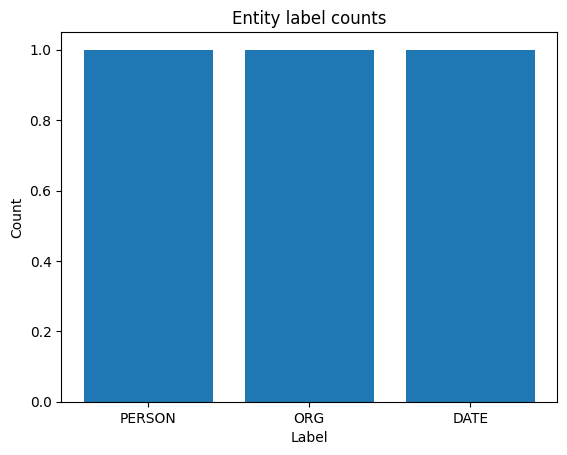

In [21]:
if counts:
    labels, values = zip(*counts.items())
    plt.figure()
    plt.bar(labels, values)
    plt.title("Entity label counts")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()
else:
    print("No entities in text.")

## Custom Entity Rules
Use `EntityRuler` to add domain-specific entities (e.g., skills).

In [22]:
from spacy.pipeline import EntityRuler
ruler = nlp.add_pipe("entity_ruler", before="ner")
patterns = [
    {"label": "SKILL", "pattern": "Python"},
    {"label": "SKILL", "pattern": "Pandas"}
]
ruler.add_patterns(patterns)

doc2 = nlp("Python and Pandas are popular in data science.")
[(ent.text, ent.label_) for ent in doc2.ents]

[('Python', 'SKILL'), ('Pandas', 'SKILL')]